## House Price Prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Load & Initial Inspection

In [61]:
df = pd.read_csv("../data/bengaluru_house_prices.csv")

print("Shape:", df.shape)
print("\nMissing values (%):\n", df.isnull().mean().mul(100).round(2))
df.head()

Shape: (13320, 9)

Missing values (%):
 area_type        0.00
availability     0.00
location         0.01
size             0.12
society         41.31
total_sqft       0.00
bath             0.55
balcony          4.57
price            0.00
dtype: float64


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 2. Feature Engineering
`size` column contains values like "2 BHK", "4 Bedroom" — extract the number as `bhk` and the type as `type`.

In [6]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [8]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [9]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [10]:
df.isnull().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

## Data Cleaning and Preprocessing (Also Handling Missing values)

In [11]:
df['size'] = df['size'].astype(str)
## Dropping missing values
df.dropna(subset=['location'], inplace=True)
df.dropna(subset=['size'], inplace=True)

In [12]:
## Created two new Columns from size
df['bhk'] = df['size'].apply(lambda x: x.split(' ')[0])
# df.dropna(subset='bhk',inplace=True)

df['type'] = df['size'].apply(
    lambda x: x.split(' ')[1] if len(x.split(' ')) > 1 else "Unknown")

df.drop(columns='size',axis=1,inplace=True)

In [13]:
## Checking type
df['type'] = df['type'].str.replace('Bedroom','BHK')
df['type'].unique()

array(['BHK', 'RK', 'Unknown'], dtype=object)

In [14]:
## Dropping Society column as many values are missing
df.drop("society",axis=1,inplace=True)

In [15]:
## Filling balcony and bath with median values
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
df['bath'] = df['bath'].fillna(df['bath'].median())

In [16]:
df.isnull().mean()*100

area_type       0.0
availability    0.0
location        0.0
total_sqft      0.0
bath            0.0
balcony         0.0
price           0.0
bhk             0.0
type            0.0
dtype: float64

In [17]:
## Some nan values still there in bhk... not removed
df['bhk'].isnull().sum()

np.int64(0)

In [18]:
## Converting bhk to numeric.. if any errors make it as Nan and filling it with median values
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')
df['bhk'] = df['bhk'].fillna(df['bhk'].median())

In [19]:
## Converting float columns to integer
df['bhk'] = df['bhk'].astype(int)
df['bath'] = df['bath'].astype(int)
df['balcony'] = df['balcony'].astype(int)

In [20]:
## Removed bhk with more than 10 cause its not realistic
df = df[(df['bhk'] >=1) & (df['bhk'] <= 10)]
df = df[(df['bath'] >=1) & (df['bath'] <= 10)]

In [21]:
df['bhk'].value_counts()
# df['bath'].value_counts()

bhk
2     5528
3     4872
4     1417
1      656
5      356
6      221
7      100
8       86
9       50
10      10
Name: count, dtype: int64

In [22]:
df.duplicated().sum()

np.int64(569)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
## total_sqft has ranges so making a custom function to remove those
def convert_sqft(x):
    x = str(x)
    if "-" in x:
        a,b = x.split("-")
        return (float(a)+float(b))/2
    
    try:
        return float(x)
    except:
        return np.nan


df['total_sqft'] = df['total_sqft'].apply(convert_sqft)    


In [25]:
df.dropna(subset='total_sqft',inplace=True)
df['total_sqft'] = df['total_sqft'].astype(int)

In [26]:
df.drop(columns="availability",axis=1,inplace = True)

In [27]:
df.corr(numeric_only=True)

,total_sqft,bath,balcony,price,bhk
total_sqft,1.000000,0.397230,0.153570,0.578789,0.354452
bath,0.397230,1.000000,0.231831,0.467276,0.879387
balcony,0.153570,0.231831,1.000000,0.125599,0.218092
price,0.578789,0.467276,0.125599,1.000000,0.409402
bhk,0.354452,0.879387,0.218092,0.409402,1.000000


In [28]:
df.isnull().sum()

area_type     0
location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
type          0
dtype: int64

## Removing Outliers

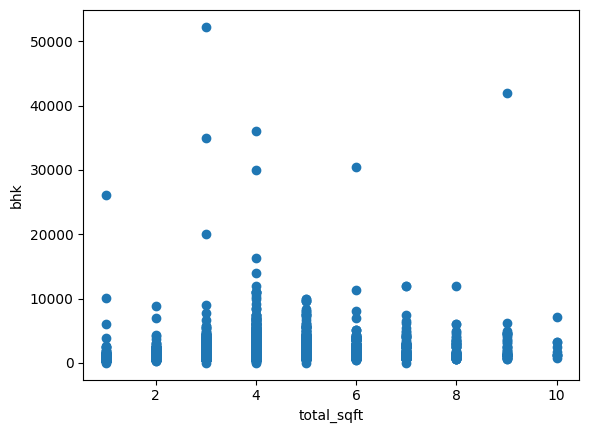

In [29]:
## Scatterplot
plt.scatter(df['bhk'],df['total_sqft'])
plt.xlabel("total_sqft")
plt.ylabel("bhk")
plt.show()

In [30]:
## We can observe from the scatterplot that the houses with less and more total sqft have the same price
## There are outliers present
## How can houses with more bhk.. have total area close to 0 sqft.. min should be a 100 

(df["total_sqft"]/df['bhk']).describe()

count    12681.000000
mean       576.464305
std        395.493958
min          0.250000
25%        474.333333
50%        552.500000
75%        626.666667
max      26136.000000
dtype: float64

In [31]:
len(df)

12681

In [32]:
## Removed data with less than 300 sqft we chose 300 because if you see describe 25 percent to 75 percent quartile range is 474 - 626 mostly
## So we chose a safe number less than 474 otherwise good data may be removed
df = df[df["total_sqft"]/df['bhk'] >= 300]

In [33]:
## We can observe from the scatterplot that the houses with less and more total sqft have the same price
## There are outliers present
## How can houses with more bhk.. have total area close to 0 sqft.. min should be a 100 

(df["total_sqft"]/df['bhk']).describe()

count    11962.000000
mean       599.530210
std        395.265908
min        300.000000
25%        492.500000
50%        563.000000
75%        633.000000
max      26136.000000
dtype: float64

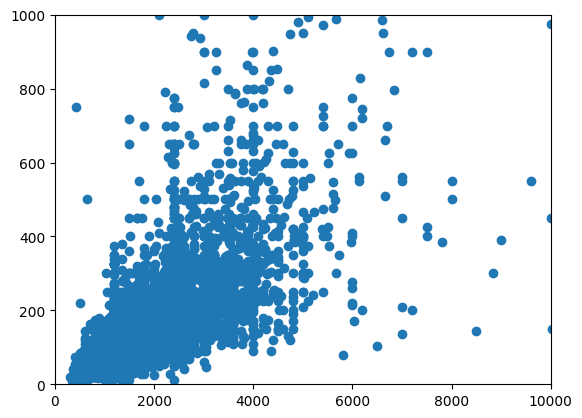

In [34]:
# plt.scatter(df['total_sqft'], df['price'])
# plt.xlabel("total_sqft")
# plt.ylabel("price")
# plt.show()

plt.scatter(df['total_sqft'], df['price'])
plt.xlim(0, 10000)
plt.ylim(0, 1000)
plt.show()

In [35]:
lower = df['total_sqft'].quantile(0.01)
upper = df['total_sqft'].quantile(0.99)

df = df[(df['total_sqft'] >= lower) & (df['total_sqft'] <=upper)]

In [36]:
## Also there can be only bathrooms + 2 max than bhk otherwise its uncommon
df = df[df['bath'] <= df['bhk'] + 2]

In [37]:
## Removing the data with less than  10 counts
location_count = df['location'].value_counts()
df['location'] = df['location'].apply(
    lambda x: x if location_count[x] >= 10 else 'other'
)

In [38]:
location_count["Whitefield"]

np.int64(510)

In [39]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8107
Built-up  Area          2252
Plot  Area              1286
Carpet  Area              74
Name: count, dtype: int64

np.float64(4.25479034226796)

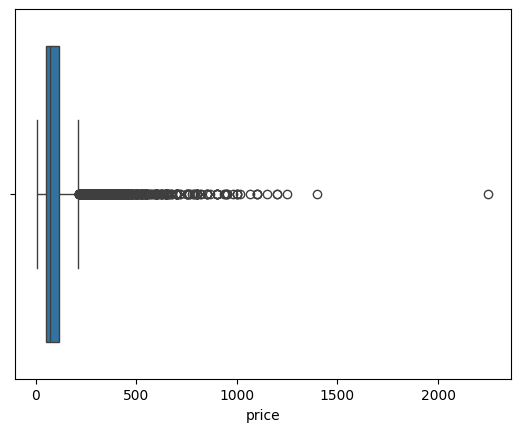

In [40]:
sns.boxplot(x=df['price'])
df['price'].skew()

In [41]:
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

df = df[(df['price'] >= lower) & (df['price'] <=upper)]

bhk
2     5123
3     4513
4     1115
1      430
5      160
6       78
7       34
8       20
9       10
10       2
Name: count, dtype: int64

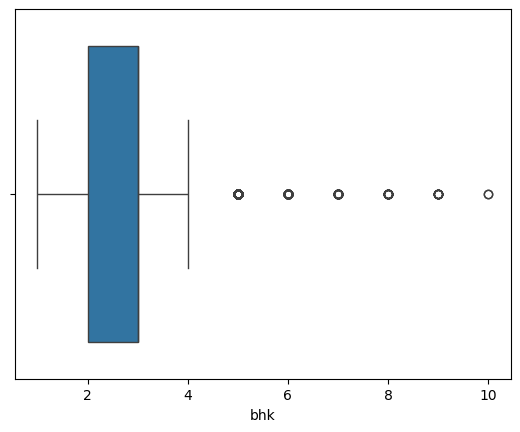

In [42]:
sns.boxplot(x=df['bhk'])
df['bhk'].value_counts()

In [43]:
df['type'].value_counts()

type
BHK        11468
Unknown       13
RK             4
Name: count, dtype: int64

In [44]:
df = df[df['type'] != 'Unknown']
df = df[df['type'] != 'RK']

In [45]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,type
0,Super built-up Area,Electronic City Phase II,1056,2,1,39.07,2,BHK
1,Plot Area,Chikka Tirupathi,2600,5,3,120.00,4,BHK
2,Built-up Area,Uttarahalli,1440,2,3,62.00,3,BHK
3,Super built-up Area,Lingadheeranahalli,1521,3,1,95.00,3,BHK
4,Super built-up Area,Kothanur,1200,2,1,51.00,2,BHK


In [46]:
x = df.drop('price',axis = 1)
y = df['price']

In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,random_state=42,test_size=0.2
)

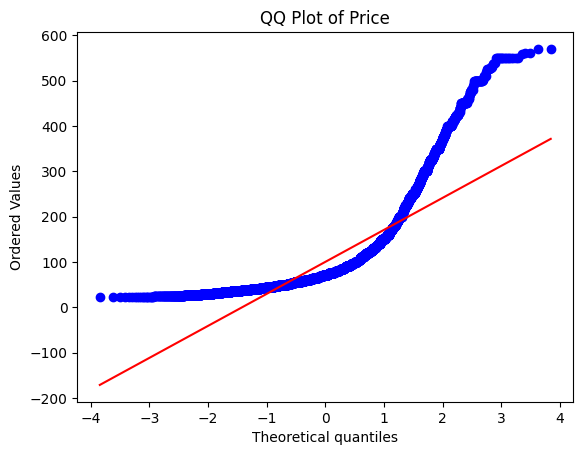

In [48]:
import scipy.stats as stats

stats.probplot(df['price'], dist="norm", plot=plt)
plt.title("QQ Plot of Price")
plt.show()

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer,StandardScaler

transformer = ColumnTransformer(
    transformers=[
        ('tnf1',OneHotEncoder(drop="first",sparse_output=False,dtype=np.int32),['area_type','location','type']),
        ('scale', StandardScaler(), ['total_sqft', 'bath', 'balcony', 'bhk'])
    ],remainder='passthrough'
)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [50]:
x_train = transformer.fit_transform(x_train)
x_test = transformer.transform(x_test)

In [51]:
x_train

array([[ 0.        ,  0.        ,  0.        , ..., -0.55316437,
        -0.76968622, -0.71632952],
       [ 0.        ,  0.        ,  1.        , ...,  1.45305421,
         0.48696111,  1.48705926],
       [ 0.        ,  1.        ,  0.        , ...,  2.4561635 ,
        -0.76968622,  1.48705926],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.44994492,
         0.48696111,  0.38536487],
       [ 0.        ,  0.        ,  1.        , ...,  0.44994492,
        -0.76968622,  0.38536487],
       [ 0.        ,  0.        ,  1.        , ..., -0.55316437,
         0.48696111, -0.71632952]], shape=(9174, 234))

In [52]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred = model.predict(x_test)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(x_test)
y_pred_actual = np.expm1(y_pred)      # reverse the log transform
y_test_actual = np.expm1(y_test)

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", mean_squared_error(y_test_actual, y_pred_actual)**0.5)
print("R2:", model.score(x_test, y_test))


MAE: 29.020394722580605
RMSE: 58.89169377489291
R2: 0.740248151942964


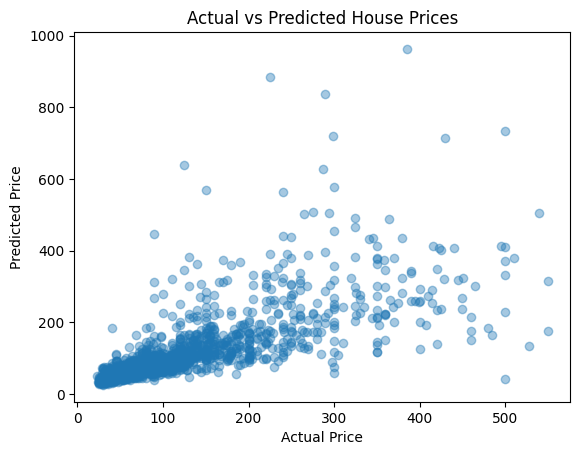

In [59]:
plt.scatter(y_test_actual, y_pred_actual, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()